<a href="https://colab.research.google.com/github/mayayonathan/A01-data-wrangling/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Maya Yonathan

**Date:** 9/6/2026

In [1]:
!git clone https://github.com/mayayonathan/A01-data-wrangling.git
%cd A01-data-wrangling

fatal: destination path 'A01-data-wrangling' already exists and is not an empty directory.
/content/A01-data-wrangling


In [2]:
import os

print(os.listdir())
print(os.listdir('./data'))

['README.md', '.git', 'data', 'GSAF5.xls', 'tidy_data.pdf', 'notebook.ipynb']
['mn_police_use_of_force.csv', 'airbnb_hw_solution_copy.xlsx', 'airbnb_hw.csv']


In [3]:
import pandas as pd

airbnb = pd.read_csv('./data/airbnb_hw.csv')

airbnb.head()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0


I cleaned the Price variable by removing commas used as thousands separators, stripping extra whitespace, and converting the values to numeric. I used errors='coerce' so that values that could not be converted would be treated as missing. After cleaning, there were 0 missing values.

In [4]:
airbnb['Price'] = (
    airbnb['Price']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
)

airbnb['Price'] = pd.to_numeric(
    airbnb['Price'],
    errors='coerce'
)

In [5]:
print(airbnb['Price'].head(20))
print("Data type:", airbnb['Price'].dtype)
print("Missing values:", airbnb['Price'].isna().sum())

0     145
1      37
2      28
3     199
4     549
5     149
6     250
7      90
8     270
9     290
10    170
11     59
12     49
13     68
14    285
15     75
16    145
17    100
18    150
19    700
Name: Price, dtype: int64
Data type: int64
Missing values: 0


In [6]:
police = pd.read_csv('./data/mn_police_use_of_force.csv')

police.head()

,response_datetime,problem,is_911_call,primary_offense,subject_injury,force_type,force_type_action,race,sex,age,type_resistance,precinct,neighborhood
0,2016/01/01 00:47:36,Assault in Progress,Yes,DASLT1,NaN,Bodily Force,Body Weight to Pin,Black,Male,20.0,Tensed,1,Downtown East
1,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,Black,Female,27.0,Verbal Non-Compliance,1,Downtown West
2,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,White,Female,23.0,Verbal Non-Compliance,1,Downtown West
3,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West
4,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West


In [7]:
police['subject_injury_clean'] = (
    police['subject_injury']
    .astype('string')
    .str.strip()
    .str.title()
)

police['subject_injury_clean'] = (
    police['subject_injury_clean']
    .where(
        police['subject_injury_clean'].isin(['Yes', 'No'])
    )
)

In [8]:
print(
    police['subject_injury_clean']
    .value_counts(dropna=False)
)

missing_prop = (
    police['subject_injury_clean']
    .isna()
    .mean()
)

print("Proportion missing:", missing_prop)
print(
    "Percent missing:",
    round(missing_prop * 100, 2),
    "%"
)

subject_injury_clean
<NA>    9848
Yes     1631
No      1446
Name: count, dtype: Int64
Proportion missing: 0.7619342359767892
Percent missing: 76.19 %


In [9]:
pd.crosstab(
    police['force_type'],
    police['subject_injury_clean'],
    dropna=False
)

subject_injury_clean,No,Yes,<NA>
force_type,,,
Baton,0,2,2
Bodily Force,1093,1286,7051
Chemical Irritant,131,41,1421
Firearm,2,0,0
Gun Point Display,33,44,27
Improvised Weapon,34,40,74
Less Lethal,0,0,87
Less Lethal Projectile,1,2,0
Maximal Restraint Technique,0,0,170


In [10]:
police['injury_missing'] = (
    police['subject_injury_clean'].isna()
)

missing_rate_by_force = (
    police.groupby('force_type')['injury_missing']
    .mean()
    .sort_values(ascending=False)
)

(missing_rate_by_force * 100).round(2)

,injury_missing
force_type,
Less Lethal,100.00
Maximal Restraint Technique,100.00
Chemical Irritant,89.20
Taser,75.36
Bodily Force,74.77
Baton,50.00
Improvised Weapon,50.00
Police K9 Bite,40.26
Gun Point Display,25.96


In [11]:
missing_prop = police['subject_injury_clean'].isna().mean()

print(round(missing_prop * 100, 2))

76.19


I cleaned subject_injury by removing extra whitespace, standardizing capitalization, and limiting valid responses to Yes and No. After cleaning, approximately 76.19% of observations were missing. This is a concern because missing injury information could affect conclusions about how frequently injuries occur during police use-of-force incidents.
The missing values are also not evenly distributed across force types. Less Lethal and Maximal Restraint Technique have 100% missing injury data, while Chemical Irritant, Taser, and Bodily Force also have high rates of missingness. In contrast, Firearm and Less Lethal Projectile have no missing injury data. This suggests that missingness is related to the type of force used and could bias comparisons across force types.

In [12]:
import os
print(os.listdir('./data'))

['mn_police_use_of_force.csv', 'airbnb_hw_solution_copy.xlsx', 'airbnb_hw.csv']


In [14]:
import os

for root, dirs, files in os.walk('/content'):
    if 'GSAF5.xls' in files:
        print(os.path.join(root, 'GSAF5.xls'))

/content/A01-data-wrangling/GSAF5.xls


In [15]:
import pandas as pd

sharks = pd.read_excel('/content/A01-data-wrangling/GSAF5.xls')
sharks.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
print("Before:", sharks.shape)

sharks = sharks.dropna(
    axis=1,
    how='all'
)

print("After:", sharks.shape)

Before: (7117, 23)
After: (7117, 23)


In [17]:
print(sharks['Year'].head(20))

sharks['Year_clean'] = pd.to_numeric(
    sharks['Year'],
    errors='coerce'
)

print(
    "Minimum year:",
    sharks['Year_clean'].min()
)

print(
    "Maximum year:",
    sharks['Year_clean'].max()
)

0     2026.0
1     2026.0
2     2026.0
3     2026.0
4     2026.0
5     2026.0
6     2026.0
7     2026.0
8     2026.0
9     2026.0
10    2026.0
11    2026.0
12    2026.0
13    2026.0
14    2026.0
15    2026.0
16    2026.0
17    2026.0
18    2026.0
19    2026.0
Name: Year, dtype: float64
Minimum year: 0.0
Maximum year: 2026.0


In [18]:
sharks_since_1940 = sharks[
    sharks['Year_clean'] >= 1940
].copy()

<Axes: title={'center': 'Shark Attacks by Year Since 1940'}, xlabel='Year', ylabel='Number of Attacks'>

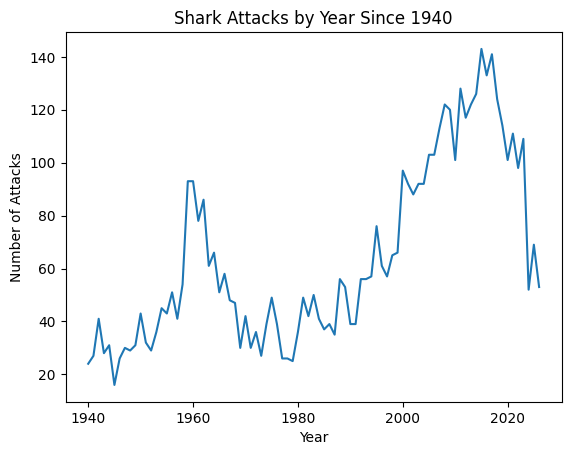

In [19]:
attacks_by_year = (
    sharks_since_1940
    .groupby('Year_clean')
    .size()
)

attacks_by_year.plot(
    title='Shark Attacks by Year Since 1940',
    xlabel='Year',
    ylabel='Number of Attacks'
)

Reported shark attacks generally increase over the period since 1940, although there is substantial year-to-year variation.

In [20]:
sharks['Age_clean'] = pd.to_numeric(
    sharks['Age'],
    errors='coerce'
)

print(sharks['Age_clean'].describe())

count    3948.000000
mean       28.197315
std        14.697518
min         1.000000
25%        17.000000
50%        24.000000
75%        37.000000
max        87.000000
Name: Age_clean, dtype: float64


<Axes: >

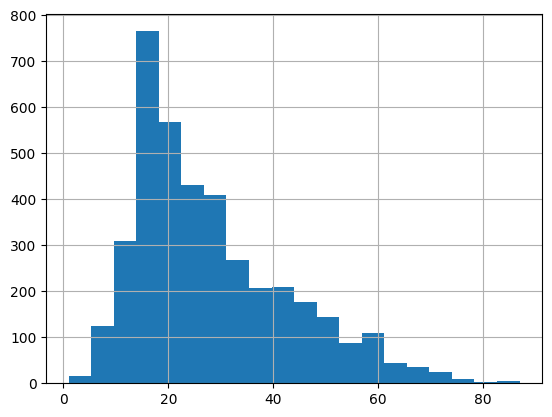

In [21]:
sharks['Age_clean'].dropna().hist(
    bins=20
)

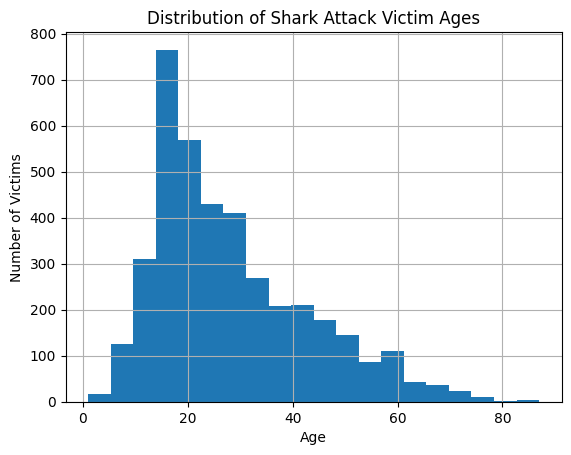

In [22]:
import matplotlib.pyplot as plt

sharks['Age_clean'].dropna().hist(
    bins=20
)

plt.xlabel('Age')
plt.ylabel('Number of Victims')
plt.title('Distribution of Shark Attack Victim Ages')
plt.show()

Victim ages are concentrated among younger and middle-aged individuals, with fewer observations at older ages. The distribution is somewhat right-skewed because there are a smaller number of much older victims.


In [23]:
sharks['Sex'].value_counts(
    dropna=False
)

,count
Sex,
M,5704
F,816
NaN,578
M,7
?,2
N,2
F,2
M F,1
M,1


In [24]:
sex_clean = (
    sharks['Sex']
    .astype('string')
    .str.strip()
    .str.upper()
)

In [25]:
known_sex = sex_clean.isin(['M', 'F'])

male_prop = (
    (sex_clean[known_sex] == 'M')
    .mean()
)

print(
    "Proportion male:",
    male_prop
)

print(
    "Percent male:",
    round(male_prop * 100, 2),
    "%"
)

Proportion male: 0.8747511866482928
Percent male: 87.48 %


In [26]:
sharks['Type'].value_counts(
    dropna=False
)

,count
Type,
Unprovoked,5261
Provoked,647
Invalid,552
Watercraft,355
Sea Disaster,242
Questionable,27
NaN,18
Boat,7
Provoked,2


In [27]:
def clean_type(value):
    if pd.isna(value):
        return 'Unknown'

    value = str(value).strip().lower()

    if value == 'provoked':
        return 'Provoked'

    elif value == 'unprovoked':
        return 'Unprovoked'

    else:
        return 'Unknown'

In [28]:
sharks['Type_clean'] = (
    sharks['Type']
    .apply(clean_type)
)

sharks['Type_clean'].value_counts()

,count
Type_clean,
Unprovoked,5263
Unknown,1205
Provoked,649


In [29]:
unprovoked_prop = (
    sharks['Type_clean']
    .eq('Unprovoked')
    .mean()
)

print(
    "Proportion unprovoked:",
    unprovoked_prop
)

print(
    "Percent unprovoked:",
    round(unprovoked_prop * 100, 2),
    "%"
)

Proportion unprovoked: 0.7394969790642124
Percent unprovoked: 73.95 %


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 91c6bc9
- **AI tool and model used:** ChatGPT, GPT-5.6 Sol

### *Prompts used

1. Can you review my Phase 1 data-wrangling code and suggest improvements for the AI-assisted revision? I want the cleaning to be more robust without completely changing my approach.
2. Can you revise my Airbnb Price cleaning, Minnesota police subject_injury cleaning, and shark attack Year, Age, Sex, and Type code so it handles missing values and invalid values more carefully?
3. Can you explain which AI-proposed changes are worth accepting and how I can verify that the revised cleaning worked correctly?

### *AI-proposed changes


1. Clean the Airbnb Price column in a separate variable before replacing the original column, and remove commas, dollar signs, and surrounding whitespace before numeric conversion.
2. Simplify the subject_injury cleaning by standardizing capitalization and explicitly keeping only Yes and No, while preserving missing values.
3. Add clearer validation checks after cleaning, such as printing valid categories and missing-value counts.
4. For the shark data, convert Year and Age with pd.to_numeric(errors='coerce') and filter implausible values before analysis.
5. Calculate proportions using only observations with known values when appropriate, so missing values are not accidentally treated as No or another category.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 |	Accept |	Removing $, commas, and whitespace makes the price cleaning more robust. I verified that Price became numeric and checked the missing count. |
| 2 | Accept |	Explicitly restricting injury values to Yes and No prevents unexpected categories from remaining. I checked value_counts(dropna=False). |
| 3	| Accept |	Adding validation output made it easier to confirm the cleaning worked correctly. |
| 4 | Accept |	Filtering implausible years and ages prevents numeric but invalid values from affecting the analysis. |
| 5	| Accept |	Using only known sex values gives a more meaningful proportion because missing values are not treated as non-male. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [30]:
import pandas as pd

airbnb = pd.read_csv('./data/airbnb_hw.csv')

price_clean = (
    airbnb['Price']
    .astype('string')
    .str.replace(',', '', regex=False)
    .str.replace('$', '', regex=False)
    .str.strip()
)

airbnb['Price'] = pd.to_numeric(
    price_clean,
    errors='coerce'
)

print("Missing prices:", airbnb['Price'].isna().sum())
print("Price dtype:", airbnb['Price'].dtype)

airbnb['Price'].describe()

Missing prices: 0
Price dtype: Int64


,Price
count,30478.0
mean,163.589737
std,197.785454
min,10.0
25%,80.0
50%,125.0
75%,195.0
max,10000.0


In [31]:
police = pd.read_csv('./data/mn_police_use_of_force.csv')

police['subject_injury_clean'] = (
    police['subject_injury']
    .astype('string')
    .str.strip()
    .str.title()
)

police.loc[
    ~police['subject_injury_clean'].isin(['Yes', 'No']),
    'subject_injury_clean'
] = pd.NA

print(
    police['subject_injury_clean']
    .value_counts(dropna=False)
)

subject_injury_clean
<NA>    9848
Yes     1631
No      1446
Name: count, dtype: Int64


In [32]:
missing_prop = (
    police['subject_injury_clean']
    .isna()
    .mean()
)

print(
    "Percent missing:",
    round(missing_prop * 100, 2),
    "%"
)

Percent missing: 76.19 %


In [33]:
injury_force_table = pd.crosstab(
    police['force_type'],
    police['subject_injury_clean'],
    dropna=False
)

injury_force_table

subject_injury_clean,No,Yes,<NA>
force_type,,,
Baton,0,2,2
Bodily Force,1093,1286,7051
Chemical Irritant,131,41,1421
Firearm,2,0,0
Gun Point Display,33,44,27
Improvised Weapon,34,40,74
Less Lethal,0,0,87
Less Lethal Projectile,1,2,0
Maximal Restraint Technique,0,0,170


In [34]:
police['injury_missing'] = (
    police['subject_injury_clean']
    .isna()
)

missing_rate_by_force = (
    police.groupby('force_type')['injury_missing']
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

missing_rate_by_force

,injury_missing
force_type,
Less Lethal,100.00
Maximal Restraint Technique,100.00
Chemical Irritant,89.20
Taser,75.36
Bodily Force,74.77
Baton,50.00
Improvised Weapon,50.00
Police K9 Bite,40.26
Gun Point Display,25.96


In [36]:
sharks = pd.read_excel('/content/A01-data-wrangling/GSAF5.xls')

print("Original shape:", sharks.shape)

sharks = sharks.dropna(
    axis=1,
    how='all'
)

print("Shape after dropping empty columns:", sharks.shape)

sharks.head()

Original shape: (7117, 23)
Shape after dropping empty columns: (7117, 23)


,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
sharks['Year_clean'] = pd.to_numeric(
    sharks['Year'],
    errors='coerce'
)

sharks.loc[
    (sharks['Year_clean'] < 1900) |
    (sharks['Year_clean'] > 2026),
    'Year_clean'
] = pd.NA

print(
    "Minimum year:",
    sharks['Year_clean'].min()
)

print(
    "Maximum year:",
    sharks['Year_clean'].max()
)

Minimum year: 1900.0
Maximum year: 2026.0


<Axes: title={'center': 'Shark Attacks by Year Since 1940'}, xlabel='Year', ylabel='Number of Attacks'>

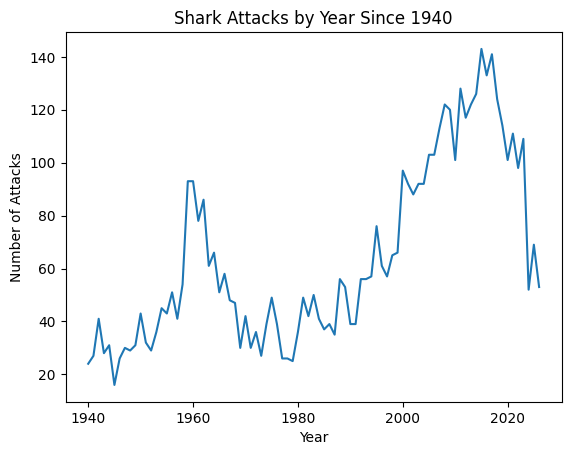

In [38]:
sharks_since_1940 = sharks[
    sharks['Year_clean'] >= 1940
].copy()

attacks_by_year = (
    sharks_since_1940
    .groupby('Year_clean')
    .size()
)

attacks_by_year.plot(
    title='Shark Attacks by Year Since 1940',
    xlabel='Year',
    ylabel='Number of Attacks'
)

In [39]:
sharks['Age_clean'] = pd.to_numeric(
    sharks['Age'],
    errors='coerce'
)

sharks.loc[
    (sharks['Age_clean'] < 0) |
    (sharks['Age_clean'] > 110),
    'Age_clean'
] = pd.NA

print(
    sharks['Age_clean']
    .describe()
)

count    3948.000000
mean       28.197315
std        14.697518
min         1.000000
25%        17.000000
50%        24.000000
75%        37.000000
max        87.000000
Name: Age_clean, dtype: float64


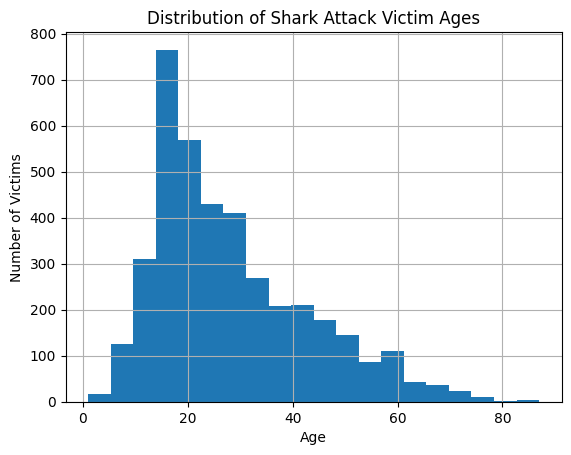

In [40]:
import matplotlib.pyplot as plt

sharks['Age_clean'].dropna().hist(
    bins=20
)

plt.xlabel('Age')
plt.ylabel('Number of Victims')
plt.title('Distribution of Shark Attack Victim Ages')
plt.show()

In [41]:
sex_clean = (
    sharks['Sex']
    .astype('string')
    .str.strip()
    .str.upper()
)

known_sex = sex_clean.isin(['M', 'F'])

male_prop = (
    sex_clean[known_sex]
    .eq('M')
    .mean()
)

print(
    "Percent male:",
    round(male_prop * 100, 2),
    "%"
)

Percent male: 87.48 %


In [42]:
type_clean = (
    sharks['Type']
    .astype('string')
    .str.strip()
    .str.lower()
)

sharks['Type_clean'] = 'Unknown'

sharks.loc[
    type_clean == 'provoked',
    'Type_clean'
] = 'Provoked'

sharks.loc[
    type_clean == 'unprovoked',
    'Type_clean'
] = 'Unprovoked'

print(
    sharks['Type_clean']
    .value_counts()
)

Type_clean
Unprovoked    5263
Unknown       1205
Provoked       649
Name: count, dtype: int64


In [43]:
unprovoked_prop = (
    sharks['Type_clean']
    .eq('Unprovoked')
    .mean()
)

print(
    "Percent unprovoked:",
    round(unprovoked_prop * 100, 2),
    "%"
)

Percent unprovoked: 73.95 %


### *Reflection on AI assistance
In your own words without generative AI.


The main improvements were making the cleaning steps more careful and adding checks to make sure the results actually made sense. For the Airbnb data, I cleaned the Price column by removing commas, dollar signs, and extra spaces before converting it to numbers. For the police data, I standardized subject_injury so only Yes and No were kept as valid values. For the shark data, I cleaned the Year and Age columns by converting invalid entries to missing values and checking for unrealistic values.
One issue with the AI help was that some suggestions still required judgment, like deciding what counts as an unrealistic age or year. There were also some file path problems in Colab that had to be corrected manually. I verified the final solution by checking missing values, data types, category counts, summary statistics, and plots. My main remaining concern is that missing police injury data could still affect the conclusions.
